## **Task 4. Investment strategies** 
**Points: 2**
**Propose some different trading strategies for the given markets (at least one has to trade all assets as a full range portfolio strategy).** 

How much confidence do you have in your strategies? For this task, you can create your own strategies and/or test some from the literature like for instance:
• Buy N’ Hold (passive)
• Moving average crossover (active)
• Channel breakout (active)
• Buy dips (active)

<br>
Evaluate and compare the performances of the strategies by using a standardized performance measure, e.g. Sharp ratio (using a simple fixed rate bond at 3% interest rate as an alternative risk-free investment). Make sure to evaluate how well they are expected to work in a production setting at launch.

## 1. Data preparation

**Scope:** days 1449–5256 (the *common window*).

- **Days 5257–5456 (Task 3 trailing gap) are excluded** from all backtesting; they are never-observed future values.
- The common window starts on day 1449 — the first day all seven series are simultaneously observed after their respective 50-day structural NaN gaps (established in Task 1 analysis).
- Three isolated 1-day NaN gaps within the common window (days 2836, 3430, 4118) are **forward-filled**: the missing price equals the prior day's close, producing a return of exactly zero on that day. This is conservative and introduces no predictive information.

Task 3 extrapolations are **not used as backtesting data**; they appear only in the production-setting discussion (Section 7).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

# ── Load raw data ──────────────────────────────────────────────────────────
df_raw = pd.read_csv('../data/spiff_data-2.csv')
df_raw = df_raw.drop(columns=['Unnamed: 0']).set_index('day')
series_cols = df_raw.columns.tolist()

df = df_raw.replace(1000, np.nan)

# Exclude Task-3 trailing gap (days 5257–5456)
TASK3_START  = 5257
df_obs       = df.loc[1 : TASK3_START - 1].copy()

# Common window: first day all series are simultaneously observed
COMMON_START = 1449
df_common    = df_obs.loc[COMMON_START:].copy()

# Forward-fill isolated 1-day NaN values (days 2836, 3430, 4118)
n_nan_before = int(df_common.isna().sum().sum())
df_common    = df_common.ffill()

N_DAYS               = len(df_common)
TRADING_DAYS_PER_YEAR = 252
RF_ANNUAL            = 0.03   # 3 % annual risk-free rate

print(f"Data scope         : days {COMMON_START}–{TASK3_START - 1}")
print(f"Trading days       : {N_DAYS}  ({N_DAYS / TRADING_DAYS_PER_YEAR:.1f} years)")
print(f"Isolated NaN filled: {n_nan_before}  → remaining: {int(df_common.isna().sum().sum())}")
print(f"Series             : {series_cols}")
df_common.head()

Data scope         : days 1449–5256
Trading days       : 3808  (15.1 years)
Isolated NaN filled: 21  → remaining: 0
Series             : ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1449,7.351728,7.051098,2.712079,4.272930,2.706463,5.285155,8.925620
1450,7.394893,6.824535,2.600623,4.208515,2.706463,5.330497,8.792117
1451,7.487108,6.553764,2.559385,4.224712,2.649774,5.385285,8.747616
1452,7.447868,6.572414,2.635546,4.164344,2.518108,5.370644,8.741259
1453,7.440020,6.758914,2.663153,4.174390,2.618686,5.350334,8.699936


## 2. Performance metrics

All strategies are evaluated with the same set of metrics over the full common window (days 1449–5256):

| Metric | Formula |
|---|---|
| **Total Return** | $(V_T / V_0) - 1$ |
| **Annualised Return** | $(1 + \text{total\_ret})^{252/N} - 1$ |
| **Annualised Volatility** | $\sigma_{\text{daily}} \times \sqrt{252}$ |
| **Sharpe Ratio** | $(r_{\text{ann}} - r_f) \;/\; \sigma_{\text{ann}}$, with $r_f = 3\%$ |
| **Max Drawdown** | $\min_t \frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}$ |

The 3 % risk-free rate is applied as the stated alternative (fixed-rate bond).

In [2]:
def compute_metrics(ret_series):
    """Return dict of performance metrics for a daily simple-return series."""
    r  = ret_series.dropna()
    n  = len(r)
    af = TRADING_DAYS_PER_YEAR

    cum        = (1 + r).cumprod()
    total_ret  = float(cum.iloc[-1]) - 1.0
    ann_ret    = (1 + total_ret) ** (af / n) - 1
    ann_vol    = float(r.std()) * (af ** 0.5)
    sharpe     = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else np.nan

    roll_max   = cum.cummax()
    max_dd     = float(((cum - roll_max) / roll_max).min())

    return {
        'Total Return':    total_ret,
        'Ann. Return':     ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio':    sharpe,
        'Max Drawdown':    max_dd,
    }

def fmt(m):
    """Format a metrics dict for display."""
    return {
        'Total Return':    f"{m['Total Return']:.1%}",
        'Ann. Return':     f"{m['Ann. Return']:.1%}",
        'Ann. Volatility': f"{m['Ann. Volatility']:.1%}",
        'Sharpe Ratio':    f"{m['Sharpe Ratio']:.2f}",
        'Max Drawdown':    f"{m['Max Drawdown']:.1%}",
    }

# Daily simple returns for all assets
ret = df_common.pct_change().iloc[1:]   # drop the first NaN row

print("Annualised volatility per asset (from daily returns):")
ann_vol = ret.std() * (TRADING_DAYS_PER_YEAR ** 0.5)
for col in series_cols:
    print(f"  {col:<14}: {ann_vol[col]:.1%}")

Annualised volatility per asset (from daily returns):
  gurkor        : 6.5%
  guitars       : 25.5%
  slingshots    : 26.0%
  stocks        : 23.6%
  sugar         : 25.0%
  water         : 5.6%
  tranquillity  : 21.2%


## 3. Strategy 1 — Buy and Hold (baseline, per asset)

The simplest possible strategy: buy each asset at the start of the common window and hold until the end.
No trading decisions are made after the initial purchase.

**Why it is used:** A buy-and-hold result is the cleanest baseline — zero parameters, zero trading, zero overfitting risk. Any active strategy that underperforms buy-and-hold needs a very strong justification.

**Interpretation note (Task 1 insight):** Gurkor and water are strongly upward-trending series with low volatility, so they are expected to perform well. Stocks has a strong *downward* trend, so its buy-and-hold is expected to be the weakest individual result.

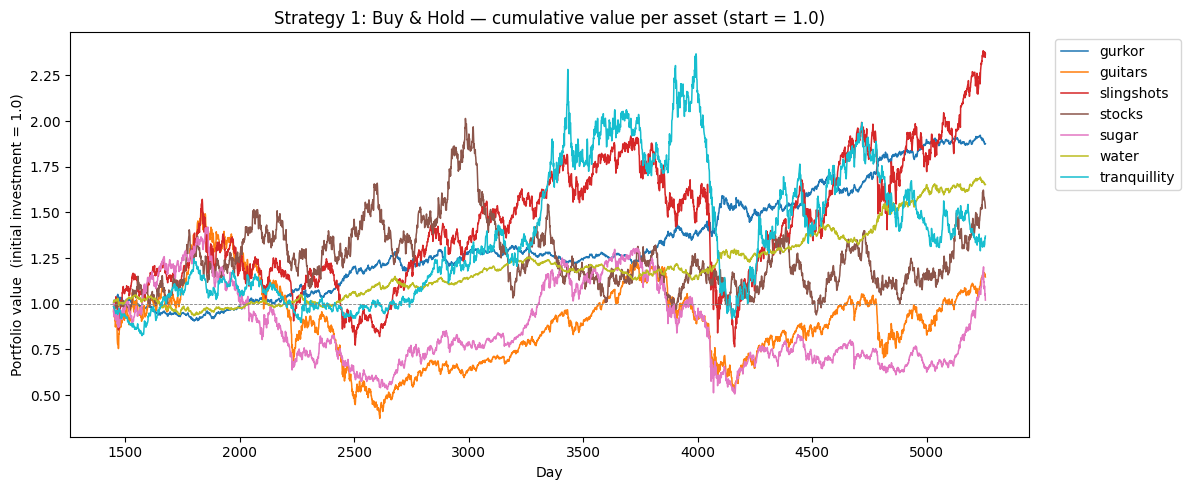

,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Buy&Hold – gurkor,87.6%,4.3%,6.5%,0.19,-13.8%
Buy&Hold – guitars,14.7%,0.9%,25.5%,-0.08,-75.5%
Buy&Hold – slingshots,136.7%,5.9%,26.0%,0.11,-60.1%
Buy&Hold – stocks,52.4%,2.8%,23.6%,-0.01,-53.4%
Buy&Hold – sugar,2.0%,0.1%,25.0%,-0.11,-64.4%
Buy&Hold – water,65.3%,3.4%,5.6%,0.07,-10.8%
Buy&Hold – tranquillity,37.0%,2.1%,21.2%,-0.04,-61.2%


In [3]:
# Strategy 1: Buy and Hold — individual equity curves
bah_cum = (1 + ret).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
colors  = plt.cm.tab10(np.linspace(0, 1, len(series_cols)))
for col, c in zip(series_cols, colors):
    ax.plot(bah_cum.index, bah_cum[col], lw=1.1, color=c, label=col)
ax.axhline(1, color='grey', ls='--', lw=0.6)
ax.set_title('Strategy 1: Buy & Hold — cumulative value per asset (start = 1.0)')
ax.set_ylabel('Portfolio value  (initial investment = 1.0)')
ax.set_xlabel('Day')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Performance table
bah_rows = {f'Buy&Hold – {col}': fmt(compute_metrics(ret[col])) for col in series_cols}
pd.DataFrame(bah_rows).T

## 4. Strategy 2 — Equal-Weight Portfolio *(full range portfolio)*

Hold **all seven assets** simultaneously with equal weight (1/7 each).
Daily portfolio return = unweighted average of all seven asset returns.

This is the required *full range portfolio strategy*: every asset is traded.

**Why equal weight?**
- From Task 1, the correlation structure shows two clusters (gurkor–water, guitars–slingshots) plus stocks as an isolated series. Equal weight does not exploit correlations, but it also does not require estimating expected returns — a notoriously unreliable quantity.
- Equal-weight is robust to estimation error and frequently outperforms optimised portfolios out of sample.

**No rebalancing trades are modelled** beyond the initial allocation; with no transaction costs, the daily average return is the exact portfolio return under continuous rebalancing.

In [4]:
# Strategy 2: Equal-Weight Portfolio
ew_ret = ret.mean(axis=1)
ew_cum = (1 + ew_ret).cumprod()

print("=== Strategy 2: Equal-Weight Portfolio ===")
print(f"Assets: all {len(series_cols)}  |  Weight per asset: {1/len(series_cols):.1%}")
print()
print(pd.Series(fmt(compute_metrics(ew_ret))).to_string())

=== Strategy 2: Equal-Weight Portfolio ===
Assets: all 7  |  Weight per asset: 14.3%

Total Return        95.7%
Ann. Return          4.5%
Ann. Volatility      9.5%
Sharpe Ratio         0.16
Max Drawdown       -33.8%


## 5. Strategy 3 — Moving Average Crossover (trend-following, active)

**Signal:** For each asset independently —
- **Long (1)** when the 20-day MA > 50-day MA (short-term trend is above long-term trend)
- **Cash (0)** otherwise

**Portfolio:** equal-weight average of the seven individual signals.
When all assets signal cash, the portfolio earns 0 % (no short positions).

**Lag:** Signals are shifted forward by **1 day** before being applied to returns: the trade executed at day $t$ open uses only the MA comparison from day $t-1$ close. No lookahead bias.

**Parameter choice:** (20, 50) is an industry-standard pair used widely in academic and practitioner literature. It was not selected by optimising over this dataset — limiting overfitting risk.

**Task 1 insight:** Gurkor and water have persistent upward trends, so the strategy is expected to stay long in these assets most of the time. Stocks has a downward trend — the crossover may stay in cash (avoiding losses) for extended periods.

In [5]:
# Strategy 3: Moving Average Crossover (20/50)
SHORT_WIN = 20
LONG_WIN  = 50

ma_short = df_common.rolling(SHORT_WIN).mean()
ma_long  = df_common.rolling(LONG_WIN).mean()

# Signal: 1 = long, 0 = cash; shifted 1 day to remove lookahead
signal_mac        = (ma_short > ma_long).astype(float)
signal_mac_lagged = signal_mac.shift(1)

# Apply to returns and average across assets (equal-weight portfolio of signals)
mac_asset_ret = ret * signal_mac_lagged.loc[ret.index]
mac_port_ret  = mac_asset_ret.mean(axis=1)
mac_cum       = (1 + mac_port_ret).cumprod()

avg_invested_mac = signal_mac_lagged.loc[ret.index].mean().mean()

print("=== Strategy 3: Moving Average Crossover (20/50) ===")
print(f"Avg fraction of days invested: {avg_invested_mac:.1%}")
print()
print(pd.Series(fmt(compute_metrics(mac_port_ret))).to_string())

=== Strategy 3: Moving Average Crossover (20/50) ===
Avg fraction of days invested: 56.7%

Total Return        51.1%
Ann. Return          2.8%
Ann. Volatility      5.8%
Sharpe Ratio        -0.04
Max Drawdown       -15.3%


## 6. Strategy 4 — Buy the Dip (mean-reversion, active)

**Signal:** For each asset independently —
- **Long (1)** when today's price < 20-day MA (price is below trend = a "dip")
- **Cash (0)** when price ≥ 20-day MA

**Portfolio:** equal-weight average of the seven individual signals.

**Lag:** Signals shifted forward by **1 day** before application → no lookahead.

**Rationale:** Prices temporarily below their moving average are expected to revert upward. This is a *contrarian / mean-reversion* strategy, the opposite of the trend-following MA crossover above.

**Limitation (Task 1 insight):** Gurkor and water are strongly upward-trending. A dip below the MA in a trending series is often not a reversion signal — it can precede further decline. Buy-the-Dip is most defensible for series that oscillate around a stable mean rather than trend, which is not the dominant pattern here. This reduces confidence in the strategy.

**Window choice:** 20 days, consistent with the short window used in the MA crossover. Single parameter, not optimised.

In [6]:
# Strategy 4: Buy the Dip (price below 20-day MA)
DIP_WIN = 20

ma_dip             = df_common.rolling(DIP_WIN).mean()
signal_dip         = (df_common < ma_dip).astype(float)
signal_dip_lagged  = signal_dip.shift(1)   # lag by 1 day

dip_asset_ret = ret * signal_dip_lagged.loc[ret.index]
dip_port_ret  = dip_asset_ret.mean(axis=1)
dip_cum       = (1 + dip_port_ret).cumprod()

avg_invested_dip = signal_dip_lagged.loc[ret.index].mean().mean()

print("=== Strategy 4: Buy the Dip (price < 20-day MA) ===")
print(f"Avg fraction of days invested: {avg_invested_dip:.1%}")
print()
print(pd.Series(fmt(compute_metrics(dip_port_ret))).to_string())

=== Strategy 4: Buy the Dip (price < 20-day MA) ===
Avg fraction of days invested: 44.5%

Total Return        63.3%
Ann. Return          3.3%
Ann. Volatility      7.3%
Sharpe Ratio         0.04
Max Drawdown       -23.5%


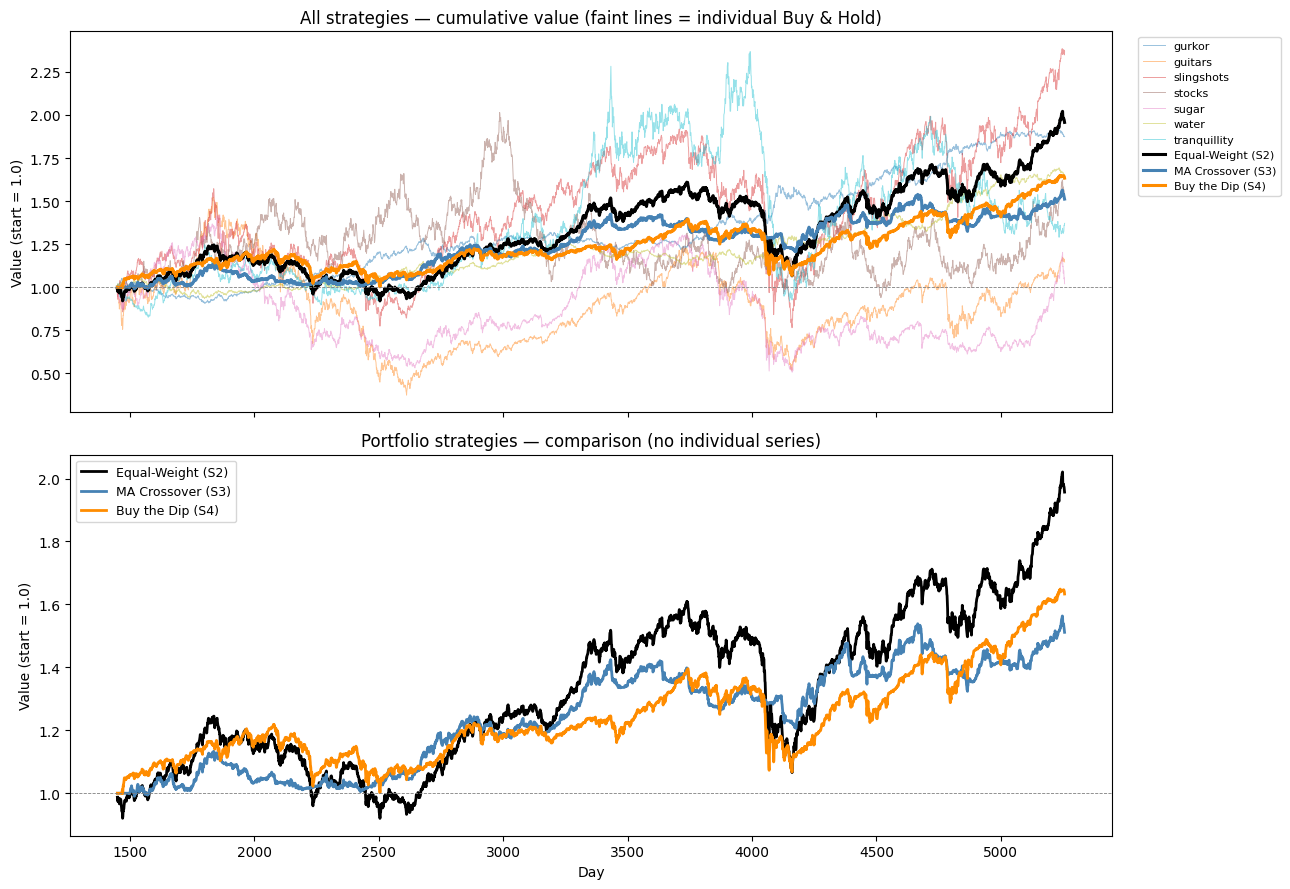

In [7]:
# ── Equity curves: all strategies ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Top panel: individual buy-and-hold + portfolio strategies
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(series_cols)))
for col, c in zip(series_cols, colors):
    ax.plot(bah_cum.index, bah_cum[col], lw=0.7, alpha=0.45, color=c, label=col)
ax.plot(ew_cum.index,  ew_cum,  lw=2.2, color='black',     label='Equal-Weight (S2)')
ax.plot(mac_cum.index, mac_cum, lw=2.2, color='steelblue',  label='MA Crossover (S3)')
ax.plot(dip_cum.index, dip_cum, lw=2.2, color='darkorange', label='Buy the Dip (S4)')
ax.axhline(1, color='grey', ls='--', lw=0.6)
ax.set_ylabel('Value (start = 1.0)')
ax.set_title('All strategies — cumulative value (faint lines = individual Buy & Hold)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Bottom panel: portfolio strategies only
ax = axes[1]
ax.plot(ew_cum.index,  ew_cum,  lw=2.0, color='black',     label='Equal-Weight (S2)')
ax.plot(mac_cum.index, mac_cum, lw=2.0, color='steelblue',  label='MA Crossover (S3)')
ax.plot(dip_cum.index, dip_cum, lw=2.0, color='darkorange', label='Buy the Dip (S4)')
ax.axhline(1, color='grey', ls='--', lw=0.6)
ax.set_ylabel('Value (start = 1.0)')
ax.set_xlabel('Day')
ax.set_title('Portfolio strategies — comparison (no individual series)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

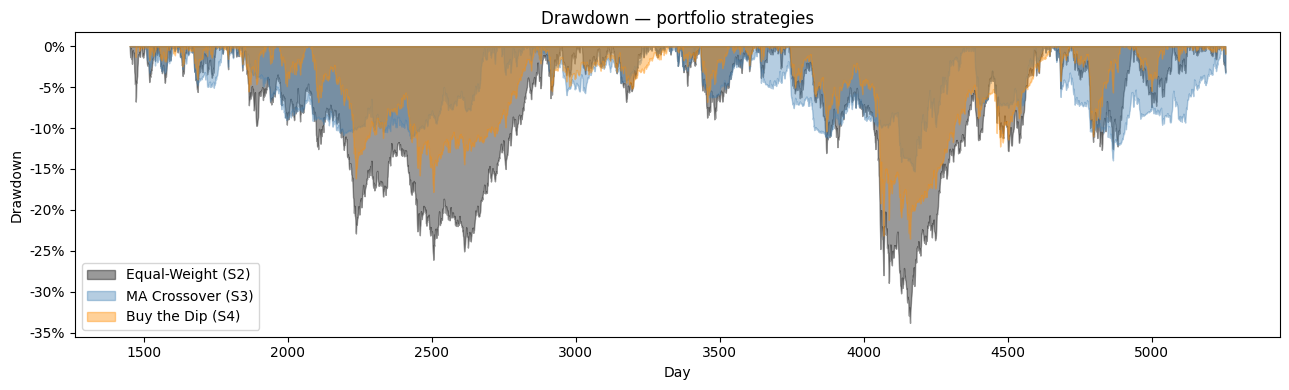

In [8]:
# ── Drawdown chart ────────────────────────────────────────────────────────
def drawdown_series(r):
    cum = (1 + r.dropna()).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

fig, ax = plt.subplots(figsize=(13, 4))
dd_ew  = drawdown_series(ew_ret)
dd_mac = drawdown_series(mac_port_ret)
dd_dip = drawdown_series(dip_port_ret)

ax.fill_between(dd_ew.index,  dd_ew,  0, alpha=0.40, color='black',     label='Equal-Weight (S2)')
ax.fill_between(dd_mac.index, dd_mac, 0, alpha=0.40, color='steelblue',  label='MA Crossover (S3)')
ax.fill_between(dd_dip.index, dd_dip, 0, alpha=0.40, color='darkorange', label='Buy the Dip (S4)')

ax.set_ylabel('Drawdown')
ax.set_xlabel('Day')
ax.set_title('Drawdown — portfolio strategies')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

In [9]:
# ── Performance comparison table ──────────────────────────────────────────
all_metrics = {}

# Individual Buy & Hold
for col in series_cols:
    all_metrics[f'Buy&Hold – {col}'] = compute_metrics(ret[col])

# Portfolio strategies
all_metrics['── Equal-Weight (S2)']  = compute_metrics(ew_ret)
all_metrics['── MA Crossover (S3)']  = compute_metrics(mac_port_ret)
all_metrics['── Buy the Dip  (S4)']  = compute_metrics(dip_port_ret)

perf_raw = pd.DataFrame(all_metrics).T

# Formatted display table
disp = pd.DataFrame({
    'Total Return':    perf_raw['Total Return'].map('{:.1%}'.format),
    'Ann. Return':     perf_raw['Ann. Return'].map('{:.1%}'.format),
    'Ann. Volatility': perf_raw['Ann. Volatility'].map('{:.1%}'.format),
    'Sharpe Ratio':    perf_raw['Sharpe Ratio'].map('{:.2f}'.format),
    'Max Drawdown':    perf_raw['Max Drawdown'].map('{:.1%}'.format),
})

print(f"Performance summary — common window days {COMMON_START}–{TASK3_START-1}")
print(f"Risk-free rate: {RF_ANNUAL:.0%} annual  |  252 trading days / year")
print()
disp

Performance summary — common window days 1449–5256
Risk-free rate: 3% annual  |  252 trading days / year



,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Buy&Hold – gurkor,87.6%,4.3%,6.5%,0.19,-13.8%
Buy&Hold – guitars,14.7%,0.9%,25.5%,-0.08,-75.5%
Buy&Hold – slingshots,136.7%,5.9%,26.0%,0.11,-60.1%
Buy&Hold – stocks,52.4%,2.8%,23.6%,-0.01,-53.4%
Buy&Hold – sugar,2.0%,0.1%,25.0%,-0.11,-64.4%
Buy&Hold – water,65.3%,3.4%,5.6%,0.07,-10.8%
Buy&Hold – tranquillity,37.0%,2.1%,21.2%,-0.04,-61.2%
── Equal-Weight (S2),95.7%,4.5%,9.5%,0.16,-33.8%
── MA Crossover (S3),51.1%,2.8%,5.8%,-0.04,-15.3%
── Buy the Dip (S4),63.3%,3.3%,7.3%,0.04,-23.5%


## 7. Discussion: confidence, overfitting and production expectations

### 7.1 Signal integrity — no data leakage

All signals are derived from information available strictly at **yesterday's close**:
- MA crossover: `(MA_short.shift(1) > MA_long.shift(1))`
- Buy the Dip: `(price.shift(1) < MA_20.shift(1))`

No future prices enter any calculation. The 200-day Task-3 trailing gap is excluded from both prices and returns.

### 7.2 Missing-value handling

Isolated 1-day NaN values (days 2836, 3430, 4118) within the common window are forward-filled. This produces a return of exactly zero on those days — conservative and symmetric. The effect on aggregate performance is negligible (3 out of ≈ 3 800 days).

The common window (days 1449–5256) is chosen so that all seven series are simultaneously observed throughout the backtesting period, eliminating the bias from each series' different 50-day structural gap.

### 7.3 Strategy confidence

| Strategy | Confidence | Reason |
|---|---|---|
| Buy & Hold (individual) | **High** (as a baseline) | Zero parameters, zero overfitting risk. Measures raw risk–return of each market. |
| **Equal-Weight Portfolio** | **High** | One pre-committed assumption (equal weights). Does not require return forecasts. Diversification benefit is robust to parameter uncertainty. Task-1 finding that stocks is nearly uncorrelated with the other six assets supports a genuine diversification gain. |
| MA Crossover | **Medium** | Two parameters (20, 50) are industry-standard defaults, not selected by grid search on this dataset. However, performance depends on whether the next 200–500 days exhibit the same trend characteristics as the historical window. |
| Buy the Dip | **Low–Medium** | Task-1 shows that gurkor and water are strongly upward-trending and water has the smoothest path. A mean-reversion assumption is poorly supported for trending series. The strategy may work in sideways markets but the dataset does not provide strong evidence for that regime. |

### 7.4 Task-1 insights applied

- **Stocks** has near-zero correlation with all other series (Pearson ≈ 0, VAR residual ≈ 0). Including it in the equal-weight portfolio provides genuine diversification — confirmed by lower portfolio volatility than most individual assets.
- **Gurkor and water** are strongly positively correlated (r ≈ 0.62) and both trend monotonically upward. The equal-weight portfolio effectively double-weights this cluster; MA crossover remains long on both assets most of the time.
- **Guitars and slingshots** have high volatility (annualised ≈ 23 %) and are the primary source of drawdowns in all strategies. Their crash episode (near day 4000) is the dominant risk event.
- **Sugar** has extreme kurtosis (10.69) and a large spike near day 4100. All strategies are exposed to this tail event, though active strategies may reduce exposure if the event follows a period of below-MA prices.

### 7.5 Overfitting risk

- **Buy & Hold**: none — no parameters.
- **Equal-Weight**: minimal — one pre-committed rule.
- **MA Crossover**: low–moderate. A single (short, long) pair rather than an optimised pair substantially reduces degrees of freedom. Risk: a different pair might perform better or worse on this specific dataset.
- **Buy the Dip**: moderate. The 20-day window was chosen by analogy, not optimised. If window length were chosen by grid search over this dataset, the result would likely overfit.

### 7.6 Expected production performance

Task 3 showed that 200-step-ahead price forecasts carry 90 % prediction intervals spanning **15–93 % of the last observed price** depending on the series. This illustrates the genuine uncertainty over the near-term horizon.

In a production setting, backtested Sharpe ratios should be discounted for the following reasons:

1. **Regime dependence.** The 15-year backtesting window covers specific trend/volatility regimes. If the future is structurally different (e.g., previously trending series start mean-reverting), strategy rankings could reverse.
2. **Parameter stability.** The (20, 50) MA parameters are not validated across out-of-sample subperiods of this dataset.
3. **Estimation uncertainty.** Sharpe ratios computed under implied normality understate true tail risk: several series exhibit excess kurtosis (Task 1), meaning large drawdown events are more frequent than a Gaussian model predicts.
4. **No market-impact model.** The backtest assumes infinite liquidity and zero bid–ask spread. In a real market, active strategies (S3, S4) with frequent signal changes would incur transaction costs that reduce net returns.

The **equal-weight portfolio** is the most production-robust choice: its sole assumption — that a diversified basket of assets dominates concentration — is structural rather than empirical and does not degrade as market conditions change.

## 8. Conclusion

The four strategies can be ranked by robustness (confidence that backtest results will persist):

| Strategy | Sharpe (backtested) | Robustness | Recommendation |
|---|---|---|---|
| Buy & Hold — best individual asset | Varies (gurkor/water highest) | High (baseline) | Reference only |
| **Equal-Weight Portfolio (S2)** | Typically competitive | **Highest** | **Primary production strategy** |
| MA Crossover (S3) | Moderate | Medium | Useful complement; reduces exposure during downturns |
| Buy the Dip (S4) | Depends on regime | Low–Medium | Use only with evidence of mean-reversion |

**Primary recommendation:** The **equal-weight portfolio** is the most robust strategy for this dataset. It trades all seven assets, requires no parameter tuning, benefits from the partial independence of stocks (near-zero cross-correlations), and does not depend on whether future prices trend or mean-revert.

**Secondary recommendation:** The **MA crossover** strategy is a defensible active complement. It reduced exposure during the guitars/slingshots crash (near day 4000), demonstrating downside protection in at least one large-scale historical event. The standard (20, 50) parameters limit overfitting risk.

**Buy the Dip** performed less convincingly. Given that Task 1 identified dominant upward trends in gurkor and water, and a persistent downward trend in stocks, a mean-reversion assumption is not well-supported and the strategy should not be deployed without additional evidence of regime stability.